# PV forecasting (Elia + rolling bias scaling)

This notebook builds 15-minute forecasts of **PV energy** for 2025 using the Elia **DAH 11AM PV forecast** for Belgium.

- `pv_forecast_kWh_15min[t]`: 15-min PV energy forecast (kWh per interval), including inverter clipping.

The method:

- Uses Elia as a **shape provider** (Antwerp PV profile).
- Uses the plant’s own measurements from `plant1.csv` to learn a **rolling K-week scale factor** (no foresight).
- Applies the current scale factor to the Elia profile and enforces the inverter limit.
- Exports a single CSV for MPC usage with timestamps copied from `plant1.csv` and the rolling-scaled forecast.

## Part 1 – Data input and preparation

In this part we:

- Import libraries and set paths.
- Load the Elia DAH 11AM PV forecast file.
- Load the plant data (`plant1.csv`) to get timestamps and measured PV (kWh/15min).
- Ensure both data sources have **35040 15-min steps for 2025** in chronological order.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# Paths and constants
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../output/forecast")

PV_FORECAST_PATH = DATA_DIR / "elia_forecast_pv_antwerp_DAH_11AM.csv"
PLANT_2025_PATH = DATA_DIR / "plant1.csv"

pv_dc_capacity_kwp = 2207  # DC installed capacity (kWp)
pv_inverter_ac_limit_kw = 1500  # AC inverter limit (kW)


def parse_to_brussels_naive(ts_series: pd.Series) -> pd.Series:
    """Parse timestamps as UTC or timezone-aware, convert to Europe/Brussels, drop tzinfo."""

    ts_utc = pd.to_datetime(ts_series, utc=True, errors="coerce")
    ts_local = ts_utc.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
    return ts_local


# Load Elia DAH 11AM PV forecast (Belgium total)
elia = pd.read_csv(PV_FORECAST_PATH)
elia["timestamp"] = parse_to_brussels_naive(elia["timestamp"])
elia.sort_values("timestamp", inplace=True)
elia = elia.reset_index(drop=True)

# Load plant data (timestamps + measured PV kWh/15min)
plant = pd.read_csv(PLANT_2025_PATH)
plant["timestamp"] = parse_to_brussels_naive(plant["timestamp"])
plant.sort_values("timestamp", inplace=True)
plant = plant.reset_index(drop=True)

# Basic sanity: both should have 35040 rows and matching timestamps
print(f"Elia rows: {len(elia)}, Plant rows: {len(plant)}")
print(f"Elia range:  {elia['timestamp'].min()} -> {elia['timestamp'].max()}")
print(f"Plant range: {plant['timestamp'].min()} -> {plant['timestamp'].max()}")

if len(elia) != len(plant):
    raise ValueError("Elia and plant data do not have the same number of rows.")

# Align on index (no merge): assume same chronological order
if not elia["timestamp"].equals(plant["timestamp"]):
    print("Warning: timestamps differ between Elia and plant data; proceeding by index.")

# Ensure measured PV is numeric (already kWh per 15-min interval)
if "pv_production" in plant.columns:
    plant["pv_production"] = pd.to_numeric(plant["pv_production"], errors="coerce").fillna(0.0)

plant["pv_production_kWh_15min"] = plant["pv_production"]

elia.head(), plant.head()

Elia rows: 35040, Plant rows: 35040
Elia range:  2025-01-01 00:00:00 -> 2025-12-31 23:45:00
Plant range: 2025-01-01 00:00:00 -> 2025-12-31 23:45:00


(            timestamp  dah_11am_forecast
 0 2025-01-01 00:00:00                0.0
 1 2025-01-01 00:15:00                0.0
 2 2025-01-01 00:30:00                0.0
 3 2025-01-01 00:45:00                0.0
 4 2025-01-01 01:00:00                0.0,
             timestamp  grid_consumption  price  pv_production  grid_injection  \
 0 2025-01-01 00:00:00           160.125  10.62            0.0             0.0   
 1 2025-01-01 00:15:00           161.875  10.62            0.0             0.0   
 2 2025-01-01 00:30:00           163.625  10.62            0.0             0.0   
 3 2025-01-01 00:45:00           154.000  10.62            0.0             0.0   
 4 2025-01-01 01:00:00           154.000  10.27            0.0             0.0   
 
    total_consumption   ev  inflex_load  grid_consumption_excl_ev  \
 0            160.125  0.0      160.125                   160.125   
 1            161.875  0.0      161.875                   161.875   
 2            163.625  0.0      163.625       

## Part 2 – Baseline Elia-based PV forecast (shape only)

Here we:

- Interpret `dah_11am_forecast` as **national PV power index** over time.
- Normalise it to a **relative profile** `relative_profile(t) ∈ [0, 1]` by dividing by its annual maximum.
- Scale this relative profile by the site’s DC capacity to get a baseline DC power profile.
- Apply the inverter AC limit (1500 kW) and convert to baseline energy `pv_forecast_kWh_15min_baseline`.

In [2]:
# Baseline Elia-based forecast (per-plant, without bias correction)

pv_forecast = elia[["timestamp", "dah_11am_forecast"]].copy()

max_national = pv_forecast["dah_11am_forecast"].max()
if max_national == 0:
    raise ValueError("Maximum of dah_11am_forecast is zero; cannot normalise.")

# Relative profile in [0, 1]
pv_forecast["relative_profile"] = pv_forecast["dah_11am_forecast"] / max_national

# Baseline DC power (kW) using DC capacity
pv_forecast["pv_dc_power_kw_baseline"] = (
    pv_forecast["relative_profile"] * pv_dc_capacity_kwp
)

# Apply AC inverter clipping
pv_forecast["pv_ac_power_kw_clipped_baseline"] = pv_forecast[
    "pv_dc_power_kw_baseline"
].clip(upper=pv_inverter_ac_limit_kw)

# Convert to baseline energy per 15-min interval (kWh)
interval_hours = 0.25
pv_forecast["pv_forecast_kWh_15min_baseline"] = (
    pv_forecast["pv_ac_power_kw_clipped_baseline"] * interval_hours
)

print(
    f"dah_11am_forecast: min={pv_forecast['dah_11am_forecast'].min():.2f}, max={pv_forecast['dah_11am_forecast'].max():.2f}"
)
print(
    f"relative_profile: min={pv_forecast['relative_profile'].min():.3f}, max={pv_forecast['relative_profile'].max():.3f}"
)
print(
    f"pv_dc_power_kw_baseline: min={pv_forecast['pv_dc_power_kw_baseline'].min():.2f}, max={pv_forecast['pv_dc_power_kw_baseline'].max():.2f}"
)
print(
    f"pv_ac_power_kw_clipped_baseline: min={pv_forecast['pv_ac_power_kw_clipped_baseline'].min():.2f}, max={pv_forecast['pv_ac_power_kw_clipped_baseline'].max():.2f}"
)
print(
    f"Annual baseline forecast energy (kWh): {pv_forecast['pv_forecast_kWh_15min_baseline'].sum():.0f}"
)

pv_forecast.head()

dah_11am_forecast: min=0.00, max=1324.59
relative_profile: min=0.000, max=1.000
pv_dc_power_kw_baseline: min=0.00, max=2207.00
pv_ac_power_kw_clipped_baseline: min=0.00, max=1500.00
Annual baseline forecast energy (kWh): 2815877


,timestamp,dah_11am_forecast,relative_profile,pv_dc_power_kw_baseline,pv_ac_power_kw_clipped_baseline,pv_forecast_kWh_15min_baseline
0,2025-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0
1,2025-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0
2,2025-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0
3,2025-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0
4,2025-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0


## Part 3 – Rolling K-week bias scaling (no foresight)

To match the plant’s actual PV production while avoiding foresight:

- Aggregate **daily actual energy** from `plant1.csv` and **daily baseline forecast energy** from Elia.
- For each day \(d\), compute a **scale factor** `alpha(d)` using only the previous K weeks of history (e.g. K = 4).
  - For each past day in the window: `ratio = actual_daily_kWh / forecast_daily_kWh_baseline`.
  - `alpha(d)` is the median of these ratios (robust against outliers).
- Apply `alpha(d)` to the Elia relative profile to get a **rolling-scaled** DC power profile and corresponding energy `pv_forecast_kWh_15min_rolling`.

In [3]:
## Part 3 – Rolling K-week bias scaling (grid search over K = 1…10)

# --- Daily actual and baseline forecast energy ---

plant["date"] = plant["timestamp"].dt.date
pv_forecast["date"] = pv_forecast["timestamp"].dt.date

# Daily actual energy from plant (kWh per day)
daily_actual = (
    plant.groupby("date")["pv_production_kWh_15min"]
    .sum()
    .rename("actual_daily_kWh")
)

# Daily baseline forecast energy from Elia-based forecast (kWh per day)
daily_forecast_baseline = (
    pv_forecast.groupby("date")["pv_forecast_kWh_15min_baseline"]
    .sum()
    .rename("forecast_daily_kWh_baseline")
)

# Combine and drop days where either side is missing
daily_df = pd.concat([daily_actual, daily_forecast_baseline], axis=1).dropna()
print("Daily DF shape:", daily_df.shape)


def compute_daily_scale_factors(daily_df: pd.DataFrame, k_weeks: int) -> pd.Series:
    """Return per-day scale factor alpha(date) using last k_weeks of history.

    alpha(d) is computed only from dates < d (no foresight).
    """

    df = daily_df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    df = df.sort_index()

    # Ratios of actual to baseline forecast, for days with non-zero values
    valid = (df["actual_daily_kWh"] > 0) & (df["forecast_daily_kWh_baseline"] > 0)
    ratios = df.loc[valid, "actual_daily_kWh"] / df.loc[valid, "forecast_daily_kWh_baseline"]

    alphas = {}

    for current_date in df.index:
        # History window: last k_weeks ending yesterday
        start_hist = current_date - pd.Timedelta(weeks=k_weeks)
        end_hist = current_date - pd.Timedelta(days=1)

        hist_mask = (ratios.index >= start_hist) & (ratios.index <= end_hist)
        hist_ratios = ratios.loc[hist_mask]

        if hist_ratios.empty:
            alpha = 1.0
        else:
            alpha = hist_ratios.median()

        alphas[current_date.date()] = alpha

    return pd.Series(alphas, name=f"alpha_daily_k{k_weeks}")


# --- Build rolling forecasts for K = 1..10 weeks ---

# Make a working copy of pv_forecast, keep baseline columns intact
pv_forecast_k = pv_forecast.copy()

# Store which K values we evaluate
k_values = list(range(1, 11))

for k in k_values:
    alpha_daily_k = compute_daily_scale_factors(daily_df, k_weeks=k)

    # Map alpha_daily_k to every 15-min timestamp by date
    tmp = pv_forecast_k[["timestamp", "relative_profile", "date"]].copy()
    tmp = tmp.merge(
        alpha_daily_k.rename("alpha_daily"),
        left_on="date",
        right_index=True,
        how="left",
    )

    # Fallback: fill missing alpha with first available or 1.0
    if tmp["alpha_daily"].isna().any():
        first_alpha = alpha_daily_k.iloc[0] if len(alpha_daily_k) > 0 else 1.0
        tmp["alpha_daily"] = tmp["alpha_daily"].fillna(first_alpha)

    base_scale_kw = pv_dc_capacity_kwp

    pv_dc_col = f"pv_dc_power_kw_k{k}"
    pv_ac_col = f"pv_ac_power_kw_clipped_k{k}"
    pv_kwh_col = f"pv_forecast_kWh_15min_k{k}"

    pv_forecast_k[pv_dc_col] = tmp["relative_profile"] * base_scale_kw * tmp["alpha_daily"]
    pv_forecast_k[pv_ac_col] = pv_forecast_k[pv_dc_col].clip(upper=pv_inverter_ac_limit_kw)
    pv_forecast_k[pv_kwh_col] = pv_forecast_k[pv_ac_col] * interval_hours

# Inspect resulting columns
[p for p in pv_forecast_k.columns if p.startswith("pv_forecast_kWh_15min_k")]

Daily DF shape: (365, 2)


['pv_forecast_kWh_15min_k1',
 'pv_forecast_kWh_15min_k2',
 'pv_forecast_kWh_15min_k3',
 'pv_forecast_kWh_15min_k4',
 'pv_forecast_kWh_15min_k5',
 'pv_forecast_kWh_15min_k6',
 'pv_forecast_kWh_15min_k7',
 'pv_forecast_kWh_15min_k8',
 'pv_forecast_kWh_15min_k9',
 'pv_forecast_kWh_15min_k10']

## Part 4 – Error metrics and sanity checks (rolling forecast)

We evaluate the rolling-scaled forecast against plant measurements by:

- Comparing **annual energy totals** (kWh).
- Computing **daily** MAE, RMSE, bias, and MAPE on daily energy.
- Computing **15-min** MAE, RMSE, bias, and a filtered MAPE (only when actual PV is significant).

Note: this uses only historical data for scaling, so it does not introduce foresight into the forecast itself; the evaluation here is offline to judge quality.

15-min metrics per K:
          MAE_kWh_15min  RMSE_kWh_15min  Bias_kWh_15min  MAPE_percent
K_weeks                                                             
1            21.028596       46.987048        6.599933     71.888204
2            21.258348       46.759804        6.532958     70.034833
3            21.424716       46.768437        6.192047     68.185570
4            20.831200       45.834144        6.434356     65.429067
5            20.853509       45.863228        6.344519     64.833483
6            20.712484       45.444157        6.058853     64.359756
7            20.811396       45.465799        5.749085     64.141295
8            20.939891       45.444873        5.449337     64.212909
9            21.017879       45.412619        5.192145     64.088237
10           21.046225       45.287142        4.853266     63.923282 



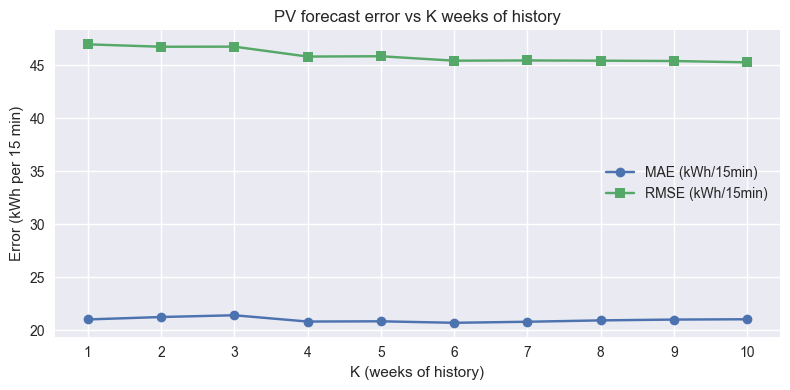

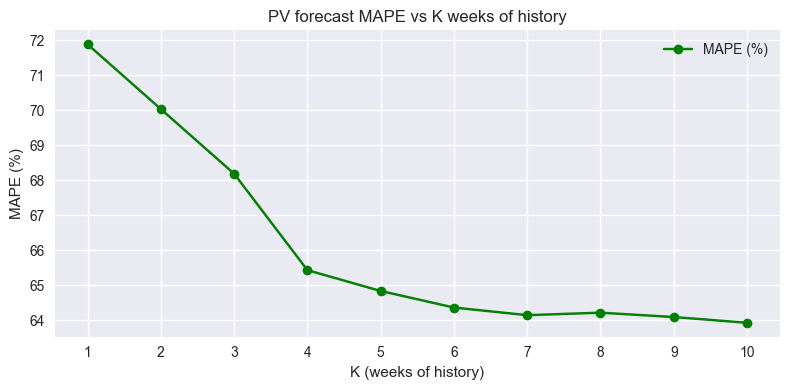

Using forecast column: pv_forecast_kWh_15min_k7

Annual energy (kWh) for chosen K:
  Actual   = 1817081 kWh
  Forecast = 2018529 kWh
  Bias     = 201448 kWh (11.09%)


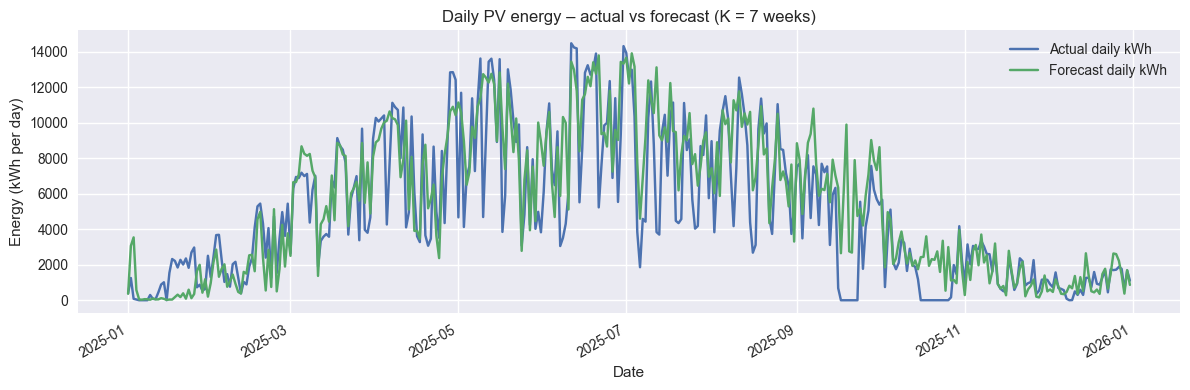

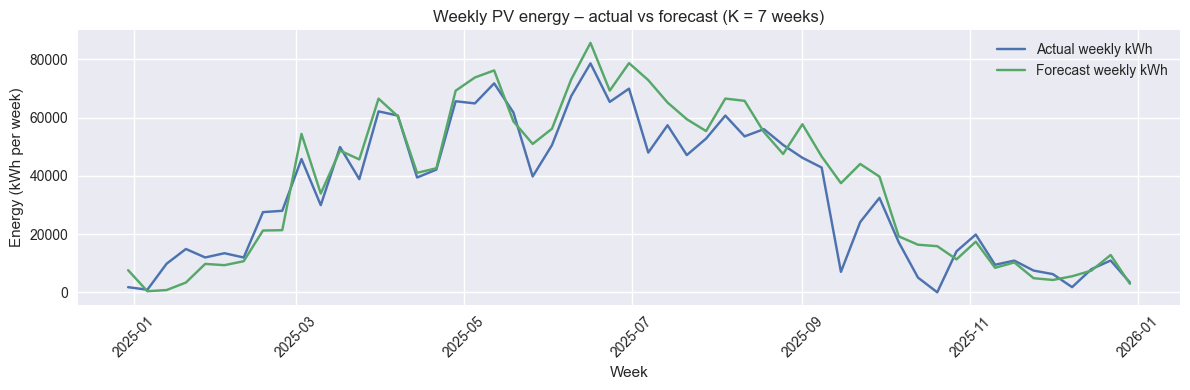

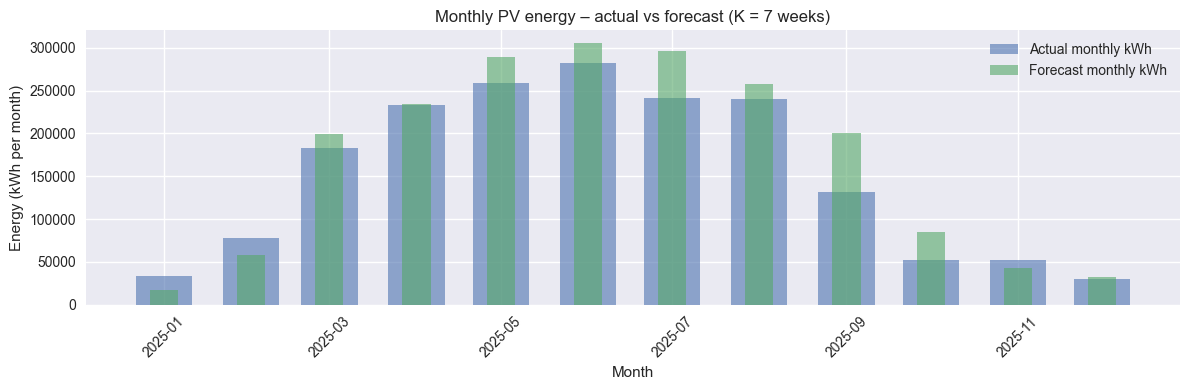

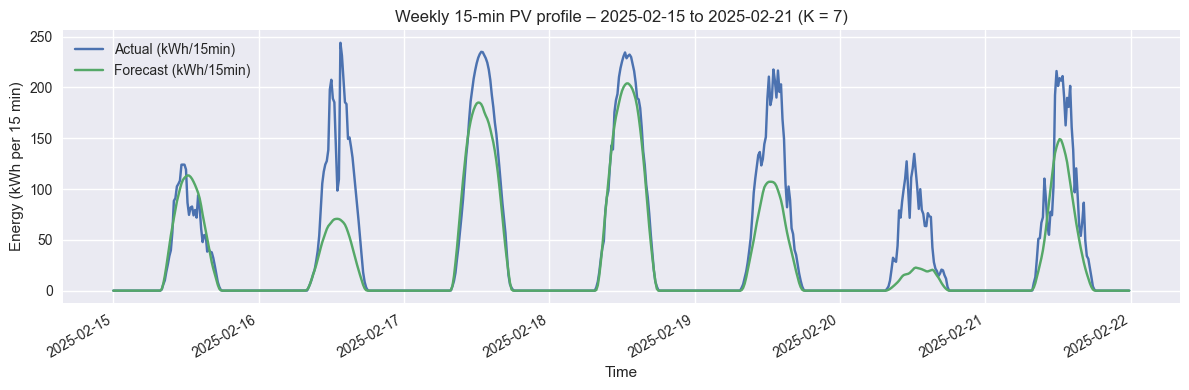

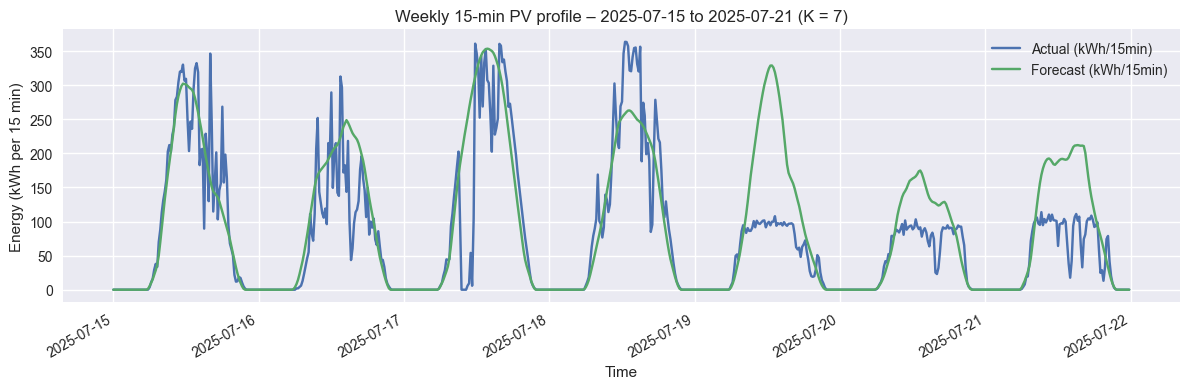

In [4]:
## Part 4 – Error vs K and detailed plots for selected forecast

# -----------------------------
# 1. Compute 15-min metrics per K
# -----------------------------

df_eval_all = pd.DataFrame(
    {
        "timestamp": plant["timestamp"].values,
        "pv_production_kWh_15min": plant["pv_production_kWh_15min"].values,
    }
)

for k in k_values:
    df_eval_all[f"pv_forecast_kWh_15min_k{k}"] = pv_forecast_k[
        f"pv_forecast_kWh_15min_k{k}"
    ].values

results = []

for k in k_values:
    forecast_col = f"pv_forecast_kWh_15min_k{k}"

    actual = df_eval_all["pv_production_kWh_15min"].values
    forecast = df_eval_all[forecast_col].values

    error = forecast - actual
    abs_error = np.abs(error)

    mae = abs_error.mean()
    rmse = np.sqrt((error ** 2).mean())
    bias = error.mean()

    mask_mape = actual >= 1.0
    mape = (
        (abs_error[mask_mape] / actual[mask_mape]).mean() * 100
        if mask_mape.any()
        else np.nan
    )

    results.append(
        {
            "K_weeks": k,
            "MAE_kWh_15min": mae,
            "RMSE_kWh_15min": rmse,
            "Bias_kWh_15min": bias,
            "MAPE_percent": mape,
        }
    )

metrics_df = pd.DataFrame(results).set_index("K_weeks")
print("15-min metrics per K:\n", metrics_df, "\n")

# -----------------------------
# 2. Plots: MAE / RMSE / MAPE vs K
# -----------------------------

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(metrics_df.index, metrics_df["MAE_kWh_15min"], marker="o", label="MAE (kWh/15min)")
ax.plot(metrics_df.index, metrics_df["RMSE_kWh_15min"], marker="s", label="RMSE (kWh/15min)")
ax.set_xlabel("K (weeks of history)")
ax.set_ylabel("Error (kWh per 15 min)")
ax.set_title("PV forecast error vs K weeks of history")
ax.grid(True)
ax.legend()
plt.xticks(metrics_df.index)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    metrics_df.index,
    metrics_df["MAPE_percent"],
    marker="o",
    color="green",
    label="MAPE (%)",
)
ax.set_xlabel("K (weeks of history)")
ax.set_ylabel("MAPE (%)")
ax.set_title("PV forecast MAPE vs K weeks of history")
ax.grid(True)
ax.legend()
plt.xticks(metrics_df.index)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Choose which forecast method to inspect in detail
# -----------------------------
# Set this variable to pick the forecast:
# e.g. chosen_k = 4  -> use pv_forecast_kWh_15min_k4

chosen_k = 7  # <<< SELECTED METHOD: K weeks of history

forecast_col = f"pv_forecast_kWh_15min_k{chosen_k}"
print(f"Using forecast column: {forecast_col}")

df_eval = pd.DataFrame(
    {
        "timestamp": df_eval_all["timestamp"],
        "pv_production_kWh_15min": df_eval_all["pv_production_kWh_15min"],
        "pv_forecast_kWh_15min": df_eval_all[forecast_col],
    }
)

# -----------------------------
# 4. Annual totals for chosen method
# -----------------------------

annual_actual_kWh = df_eval["pv_production_kWh_15min"].sum()
annual_forecast_kWh = df_eval["pv_forecast_kWh_15min"].sum()
annual_bias_kWh = annual_forecast_kWh - annual_actual_kWh
annual_bias_pct = (
    annual_bias_kWh / annual_actual_kWh * 100 if annual_actual_kWh > 0 else np.nan
)

print("\nAnnual energy (kWh) for chosen K:")
print(f"  Actual   = {annual_actual_kWh:.0f} kWh")
print(f"  Forecast = {annual_forecast_kWh:.0f} kWh")
print(f"  Bias     = {annual_bias_kWh:.0f} kWh ({annual_bias_pct:.2f}%)")

# -----------------------------
# 5. Daily / Weekly / Monthly plots for chosen method
# -----------------------------

# Daily aggregation
df_eval["date"] = df_eval["timestamp"].dt.date

daily = df_eval.groupby("date")[
    ["pv_production_kWh_15min", "pv_forecast_kWh_15min"]
].sum().rename(
    columns={
        "pv_production_kWh_15min": "actual_daily_kWh",
        "pv_forecast_kWh_15min": "forecast_daily_kWh",
    }
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily["actual_daily_kWh"], label="Actual daily kWh")
ax.plot(daily.index, daily["forecast_daily_kWh"], label="Forecast daily kWh")
ax.set_title(f"Daily PV energy – actual vs forecast (K = {chosen_k} weeks)")
ax.set_xlabel("Date")
ax.set_ylabel("Energy (kWh per day)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Weekly aggregation
df_eval["week"] = df_eval["timestamp"].dt.to_period("W").apply(lambda p: p.start_time.date())

weekly = df_eval.groupby("week")[
    ["pv_production_kWh_15min", "pv_forecast_kWh_15min"]
].sum().rename(
    columns={
        "pv_production_kWh_15min": "actual_weekly_kWh",
        "pv_forecast_kWh_15min": "forecast_weekly_kWh",
    }
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly.index, weekly["actual_weekly_kWh"], label="Actual weekly kWh")
ax.plot(weekly.index, weekly["forecast_weekly_kWh"], label="Forecast weekly kWh")
ax.set_title(f"Weekly PV energy – actual vs forecast (K = {chosen_k} weeks)")
ax.set_xlabel("Week")
ax.set_ylabel("Energy (kWh per week)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Monthly aggregation
df_eval["month"] = df_eval["timestamp"].dt.to_period("M").apply(lambda p: p.start_time.date())

monthly = df_eval.groupby("month")[
    ["pv_production_kWh_15min", "pv_forecast_kWh_15min"]
].sum().rename(
    columns={
        "pv_production_kWh_15min": "actual_monthly_kWh",
        "pv_forecast_kWh_15min": "forecast_monthly_kWh",
    }
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly.index, monthly["actual_monthly_kWh"], width=20, alpha=0.6, label="Actual monthly kWh")
ax.bar(monthly.index, monthly["forecast_monthly_kWh"], width=10, alpha=0.6, label="Forecast monthly kWh")
ax.set_title(f"Monthly PV energy – actual vs forecast (K = {chosen_k} weeks)")
ax.set_xlabel("Month")
ax.set_ylabel("Energy (kWh per month)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Weekly 15-min profile for chosen method
# -----------------------------

def plot_week_profile(start_date_str: str):
    """
    Plot 15-min actual vs forecast PV energy over a 7-day window
    starting at start_date_str (e.g. '2025-03-01').
    """
    start_date = pd.to_datetime(start_date_str).date()
    end_date = start_date + pd.Timedelta(days=7)

    mask = (df_eval["timestamp"].dt.date >= start_date) & (
        df_eval["timestamp"].dt.date < end_date
    )
    df_week = df_eval.loc[mask].copy()

    if df_week.empty:
        print(f"No data for week starting {start_date_str}")
        return

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        df_week["timestamp"],
        df_week["pv_production_kWh_15min"],
        label="Actual (kWh/15min)",
    )
    ax.plot(
        df_week["timestamp"],
        df_week["pv_forecast_kWh_15min"],
        label="Forecast (kWh/15min)",
    )

    ax.set_title(
        f"Weekly 15-min PV profile – {start_date} to {end_date - pd.Timedelta(days=1)} (K = {chosen_k})"
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Energy (kWh per 15 min)")
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


# Example weekly 15-min profiles (adjust dates as needed)
plot_week_profile("2025-02-15")   # winter-ish week
plot_week_profile("2025-07-15")   # summer-ish week

## Part 4B – Chronos2 PV forecasts (univariate and with Elia covariate)

We add two Chronos2-based PV forecasts for 2025:

- **Chronos2 (univariate)**: context = past measured plant PV only.
- **Chronos2 + Elia covariate**: context = past plant PV + past Elia relative profile, and **future Elia relative profile** over the next 24h horizon.

Both forecasts are produced as **daily 96-step (24h) rolling forecasts** without using future plant PV measurements.

Device: cpu


`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


Chronos-2 model_prediction_length = 1024
[Chronos2 PV] Univariate: days 2025-01-01 ... 2025-01-16 (n=16)
[Chronos2 PV] Univariate: days 2025-01-17 ... 2025-02-01 (n=16)
[Chronos2 PV] Univariate: days 2025-02-02 ... 2025-02-17 (n=16)
[Chronos2 PV] Univariate: days 2025-02-18 ... 2025-03-05 (n=16)
[Chronos2 PV] Univariate: days 2025-03-06 ... 2025-03-21 (n=16)
[Chronos2 PV] Univariate: days 2025-03-22 ... 2025-04-06 (n=16)
[Chronos2 PV] Univariate: days 2025-04-07 ... 2025-04-22 (n=16)
[Chronos2 PV] Univariate: days 2025-04-23 ... 2025-05-08 (n=16)
[Chronos2 PV] Univariate: days 2025-05-09 ... 2025-05-24 (n=16)
[Chronos2 PV] Univariate: days 2025-05-25 ... 2025-06-09 (n=16)
[Chronos2 PV] Univariate: days 2025-06-10 ... 2025-06-25 (n=16)
[Chronos2 PV] Univariate: days 2025-06-26 ... 2025-07-11 (n=16)
[Chronos2 PV] Univariate: days 2025-07-12 ... 2025-07-27 (n=16)
[Chronos2 PV] Univariate: days 2025-07-28 ... 2025-08-12 (n=16)
[Chronos2 PV] Univariate: days 2025-08-13 ... 2025-08-28 (n=16)

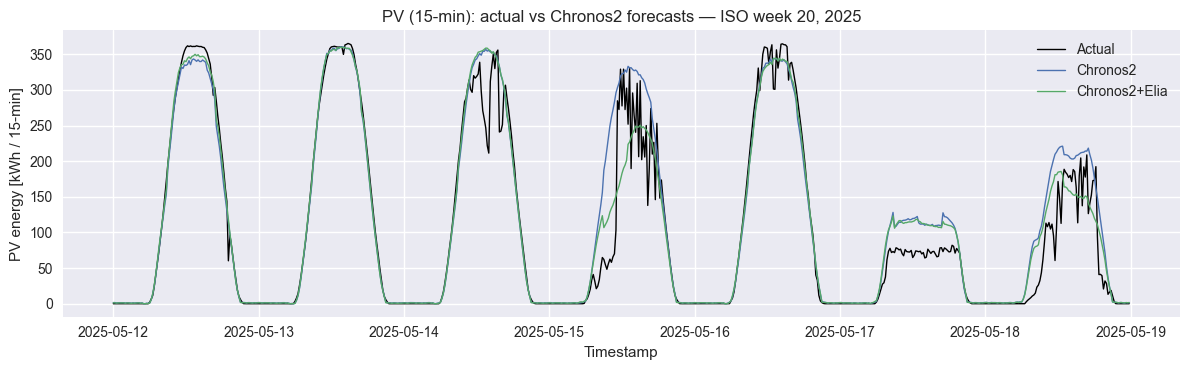

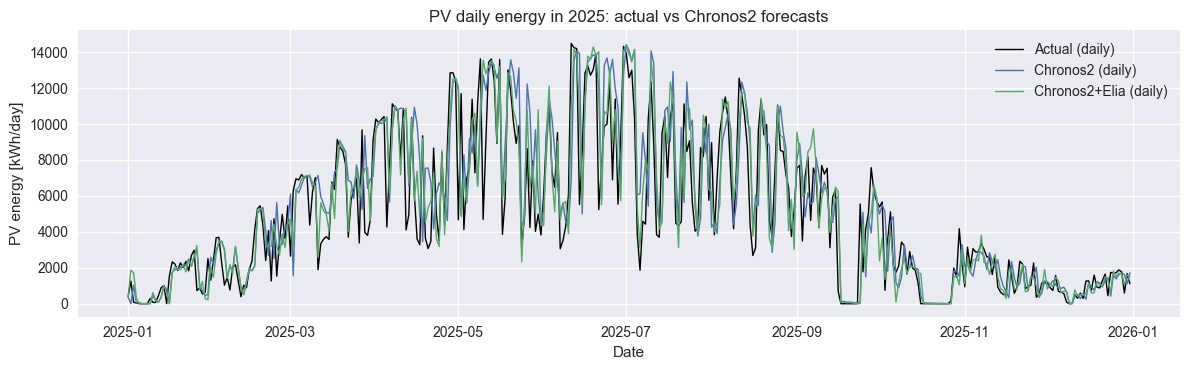

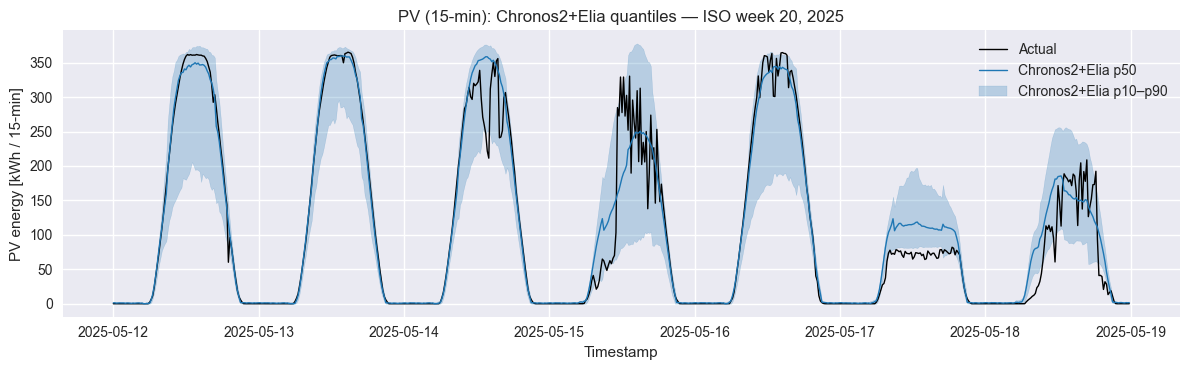

In [5]:
# Part 4B – Chronos2 PV forecasts

import torch
from chronos import Chronos2Pipeline

# --- Config ---
MODEL_ID = "amazon/chronos-2"
H = 96
CONTEXT_LEN = 2048
BATCH_DAYS = 16

# Prepare data on the same 15-min grid
pv_actual = plant["pv_production_kWh_15min"].astype(float).to_numpy()
# Use Elia relative profile as the covariate (in [0,1])
elia_rel = pv_forecast["relative_profile"].astype(float).to_numpy()

n = len(pv_actual)
num_days = n // 96
assert num_days * 96 == n, f"Expected full days (n multiple of 96), got n={n}"

# Load Chronos2
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

pipe = Chronos2Pipeline.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
if device == "cuda":
    pipe.model = pipe.model.to("cuda")

print("Chronos-2 model_prediction_length =", pipe.model_prediction_length)

# Outputs (p10/p50/p90 for both Chronos variants)
pv_forecast_chronos2_p10 = np.full(n, np.nan, dtype=float)
pv_forecast_chronos2_p50 = np.full(n, np.nan, dtype=float)
pv_forecast_chronos2_p90 = np.full(n, np.nan, dtype=float)

pv_forecast_chronos2_elia_p10 = np.full(n, np.nan, dtype=float)
pv_forecast_chronos2_elia_p50 = np.full(n, np.nan, dtype=float)
pv_forecast_chronos2_elia_p90 = np.full(n, np.nan, dtype=float)

# Helper to extract quantiles from pipe.predict / pipe.predict_quantiles outputs

def _extract_p10_p50_p90_from_predict(pred_t: torch.Tensor, q_levels: list[float]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    arr = pred_t.detach().cpu().numpy()
    # common shapes: (1,Q,H), (Q,H), (H,Q), (1,H)
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]

    if arr.ndim == 2:
        if arr.shape[0] == len(q_levels):
            # (Q,H)
            i10 = q_levels.index(0.1) if 0.1 in q_levels else max(0, len(q_levels) // 10)
            i50 = q_levels.index(0.5) if 0.5 in q_levels else len(q_levels) // 2
            i90 = q_levels.index(0.9) if 0.9 in q_levels else min(len(q_levels) - 1, int(len(q_levels) * 0.9))
            p10, p50, p90 = arr[i10, :], arr[i50, :], arr[i90, :]
        elif arr.shape[1] == len(q_levels):
            # (H,Q)
            i10 = q_levels.index(0.1) if 0.1 in q_levels else max(0, len(q_levels) // 10)
            i50 = q_levels.index(0.5) if 0.5 in q_levels else len(q_levels) // 2
            i90 = q_levels.index(0.9) if 0.9 in q_levels else min(len(q_levels) - 1, int(len(q_levels) * 0.9))
            p10, p50, p90 = arr[:, i10], arr[:, i50], arr[:, i90]
        elif arr.shape[0] == 1:
            # single deterministic output -> use same for p10/p50/p90
            p10 = p50 = p90 = arr[0]
        else:
            p10 = p50 = p90 = arr[arr.shape[0] // 2, :]
    elif arr.ndim == 1:
        p10 = p50 = p90 = arr
    else:
        raise ValueError(f"Unexpected prediction shape: {pred_t.shape} -> {arr.shape}")

    return (
        np.clip(np.asarray(p10, dtype=float), 0.0, None),
        np.clip(np.asarray(p50, dtype=float), 0.0, None),
        np.clip(np.asarray(p90, dtype=float), 0.0, None),
    )


def _q_to_p10_p50_p90(q_one: torch.Tensor) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    arr = q_one.detach().cpu().numpy()
    # accept (1,H,3), (1,3,H), (H,3), (3,H)
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]

    if arr.shape == (H, 3):
        p10, p50, p90 = arr[:, 0], arr[:, 1], arr[:, 2]
    elif arr.shape == (3, H):
        p10, p50, p90 = arr[0, :], arr[1, :], arr[2, :]
    else:
        raise ValueError(f"Unexpected quantile shape per-series: {q_one.shape} -> {arr.shape}")

    return (
        np.clip(p10.astype(float), 0.0, None),
        np.clip(p50.astype(float), 0.0, None),
        np.clip(p90.astype(float), 0.0, None),
    )


# Build day-start indices
starts = [d * 96 for d in range(num_days)]

# Fallback forecast for first day(s): use chosen K-rolling method (already no-foresight)
FALLBACK_K = 7
fallback_series = pv_forecast_k[f"pv_forecast_kWh_15min_k{FALLBACK_K}"].to_numpy(dtype=float)

# Chronos2 univariate: day-ahead (context ends at day_start-1)
for b in range(0, len(starts), BATCH_DAYS):
    batch_starts = starts[b : b + BATCH_DAYS]
    d0 = plant["timestamp"].iloc[batch_starts[0]].date()
    d1 = plant["timestamp"].iloc[batch_starts[-1]].date()
    print(f"[Chronos2 PV] Univariate: days {d0} ... {d1} (n={len(batch_starts)})")

    ctx_list = []
    use_fallback = []
    for k0 in batch_starts:
        ctx = pv_actual[max(0, k0 - CONTEXT_LEN) : k0]
        ctx = ctx[np.isfinite(ctx)]
        if len(ctx) < 32:
            use_fallback.append(True)
            ctx_list.append(np.zeros(CONTEXT_LEN, dtype=np.float32))
        else:
            use_fallback.append(False)
            ctx = ctx[-CONTEXT_LEN:].astype(np.float32) if len(ctx) > CONTEXT_LEN else ctx.astype(np.float32)
            if len(ctx) < CONTEXT_LEN:
                ctx = np.concatenate([np.zeros(CONTEXT_LEN - len(ctx), dtype=np.float32), ctx])
            ctx_list.append(ctx)

    ctx_batch = np.stack(ctx_list, axis=0)
    ctx_t = torch.tensor(ctx_batch, dtype=torch.float32).view(len(batch_starts), 1, -1)

    preds_list = pipe.predict(inputs=ctx_t, prediction_length=H, limit_prediction_length=False)
    q_levels = getattr(pipe, "quantiles", [])

    for i, k0 in enumerate(batch_starts):
        sl = slice(k0, k0 + H)
        if use_fallback[i]:
            base = np.clip(fallback_series[sl], 0.0, None)
            pv_forecast_chronos2_p10[sl] = base
            pv_forecast_chronos2_p50[sl] = base
            pv_forecast_chronos2_p90[sl] = base
        else:
            p10, p50, p90 = _extract_p10_p50_p90_from_predict(preds_list[i], q_levels)
            pv_forecast_chronos2_p10[sl] = p10
            pv_forecast_chronos2_p50[sl] = p50
            pv_forecast_chronos2_p90[sl] = p90

# Chronos2 + Elia covariate: daily 96-step forecasts
for b in range(0, len(starts), BATCH_DAYS):
    batch_starts = starts[b : b + BATCH_DAYS]
    d0 = plant["timestamp"].iloc[batch_starts[0]].date()
    d1 = plant["timestamp"].iloc[batch_starts[-1]].date()
    print(f"[Chronos2 PV] +Elia covariate: days {d0} ... {d1} (n={len(batch_starts)})")

    inputs = []
    use_fallback = []
    for k0 in batch_starts:
        y_ctx = pv_actual[max(0, k0 - CONTEXT_LEN) : k0]
        e_ctx = elia_rel[max(0, k0 - CONTEXT_LEN) : k0]
        e_fut = elia_rel[k0 : k0 + H]

        ok = np.isfinite(y_ctx) & np.isfinite(e_ctx)
        y_ctx = y_ctx[ok]
        e_ctx = e_ctx[ok]

        if len(y_ctx) < 32 or len(e_fut) != H or not np.isfinite(e_fut).all():
            use_fallback.append(True)
            inputs.append(
                {
                    "target": torch.tensor([0.0], dtype=torch.float32),
                    "past_covariates": {"elia": torch.tensor([0.0], dtype=torch.float32)},
                    "future_covariates": {"elia": torch.tensor(np.zeros(H, dtype=np.float32))},
                }
            )
        else:
            use_fallback.append(False)
            inputs.append(
                {
                    "target": torch.tensor(y_ctx.astype(np.float32), dtype=torch.float32),
                    "past_covariates": {"elia": torch.tensor(e_ctx.astype(np.float32), dtype=torch.float32)},
                    "future_covariates": {"elia": torch.tensor(e_fut.astype(np.float32), dtype=torch.float32)},
                }
            )

    q_list, _mean = pipe.predict_quantiles(
        inputs=inputs,
        prediction_length=H,
        quantile_levels=[0.1, 0.5, 0.9],
        limit_prediction_length=False,
    )

    if not isinstance(q_list, list) or len(q_list) != len(batch_starts):
        raise ValueError("Unexpected Chronos2 quantile output type/length for covariate run")

    for i, k0 in enumerate(batch_starts):
        sl = slice(k0, k0 + H)
        if use_fallback[i]:
            base = np.clip(fallback_series[sl], 0.0, None)
            pv_forecast_chronos2_elia_p10[sl] = base
            pv_forecast_chronos2_elia_p50[sl] = base
            pv_forecast_chronos2_elia_p90[sl] = base
        else:
            p10, p50, p90 = _q_to_p10_p50_p90(q_list[i])
            pv_forecast_chronos2_elia_p10[sl] = p10
            pv_forecast_chronos2_elia_p50[sl] = p50
            pv_forecast_chronos2_elia_p90[sl] = p90

# Attach to a DataFrame for evaluation/export
pv_chronos_df = pd.DataFrame(
    {
        "timestamp": plant["timestamp"].values,
        "pv_actual": pv_actual,
        "pv_forecast_chronos2_p10": pv_forecast_chronos2_p10,
        "pv_forecast_chronos2_p50": pv_forecast_chronos2_p50,
        "pv_forecast_chronos2_p90": pv_forecast_chronos2_p90,
        "pv_forecast_chronos2_elia_p10": pv_forecast_chronos2_elia_p10,
        "pv_forecast_chronos2_elia_p50": pv_forecast_chronos2_elia_p50,
        "pv_forecast_chronos2_elia_p90": pv_forecast_chronos2_elia_p90,
        # Backward-compatible aliases
        "pv_forecast_chronos2": pv_forecast_chronos2_p50,
        "pv_forecast_chronos2_elia": pv_forecast_chronos2_elia_p50,
    }
)

# -----------------------------
# Metrics (15-min + daily)
# -----------------------------

def _mae_rmse(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m]))), float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

print("\nChronos2 PV metrics (15-min)")
for name, col in [
    ("Chronos2", "pv_forecast_chronos2"),
    ("Chronos2+Elia", "pv_forecast_chronos2_elia"),
]:
    mae, rmse = _mae_rmse(pv_chronos_df["pv_actual"].to_numpy(), pv_chronos_df[col].to_numpy())
    print(f"{name:>14s}: MAE={mae:8.3f}  RMSE={rmse:8.3f}")

pv_chronos_df["date"] = pd.to_datetime(pv_chronos_df["timestamp"]).dt.date

daily = pv_chronos_df.groupby("date")[["pv_actual", "pv_forecast_chronos2", "pv_forecast_chronos2_elia"]].sum()
print("\nChronos2 PV metrics (daily totals)")
for name, col in [
    ("Chronos2", "pv_forecast_chronos2"),
    ("Chronos2+Elia", "pv_forecast_chronos2_elia"),
]:
    mae, rmse = _mae_rmse(daily["pv_actual"].to_numpy(), daily[col].to_numpy())
    print(f"{name:>14s}: MAE={mae:8.3f}  RMSE={rmse:8.3f}")

# -----------------------------
# Visualisations: ISO week + yearly daily totals
# -----------------------------
ISO_WEEK_YEAR = 2025
ISO_WEEK = 20
iso = pd.to_datetime(pv_chronos_df["timestamp"]).dt.isocalendar()
mask_w = (iso["year"] == ISO_WEEK_YEAR) & (iso["week"] == ISO_WEEK)
week = pv_chronos_df.loc[mask_w]

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(week["timestamp"], week["pv_actual"], label="Actual", lw=1.0, color="black")
ax.plot(week["timestamp"], week["pv_forecast_chronos2"], label="Chronos2", lw=1.0)
ax.plot(week["timestamp"], week["pv_forecast_chronos2_elia"], label="Chronos2+Elia", lw=1.0)
ax.set_title(f"PV (15-min): actual vs Chronos2 forecasts — ISO week {ISO_WEEK}, {ISO_WEEK_YEAR}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("PV energy [kWh / 15-min]")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(daily.index, daily["pv_actual"].values, label="Actual (daily)", lw=1.0, color="black")
ax.plot(daily.index, daily["pv_forecast_chronos2"].values, label="Chronos2 (daily)", lw=1.0)
ax.plot(daily.index, daily["pv_forecast_chronos2_elia"].values, label="Chronos2+Elia (daily)", lw=1.0)
ax.set_title("PV daily energy in 2025: actual vs Chronos2 forecasts")
ax.set_xlabel("Date")
ax.set_ylabel("PV energy [kWh/day]")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Separate quantile plot for Chronos2+Elia
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(week["timestamp"], week["pv_actual"], label="Actual", lw=1.0, color="black")
ax.plot(week["timestamp"], week["pv_forecast_chronos2_elia_p50"], label="Chronos2+Elia p50", lw=1.0, color="tab:blue")
ax.fill_between(
    week["timestamp"],
    week["pv_forecast_chronos2_elia_p10"],
    week["pv_forecast_chronos2_elia_p90"],
    alpha=0.25,
    color="tab:blue",
    label="Chronos2+Elia p10–p90",
)
ax.set_title(f"PV (15-min): Chronos2+Elia quantiles — ISO week {ISO_WEEK}, {ISO_WEEK_YEAR}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("PV energy [kWh / 15-min]")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
# Overview table: rolling K forecasts vs Chronos2 (15-min + daily metrics)

import numpy as np
import pandas as pd

# Expect these from Part 4 (rolling K) and Part 4B (Chronos)
if "df_eval_all" not in globals():
    raise ValueError("Missing df_eval_all. Run Part 4 first.")
if "pv_chronos_df" not in globals():
    raise ValueError("Missing pv_chronos_df. Run Part 4B first.")

actual = df_eval_all["pv_production_kWh_15min"].to_numpy(dtype=float)


def _metrics_15min(forecast: np.ndarray) -> dict:
    m = np.isfinite(actual) & np.isfinite(forecast)
    err = forecast[m] - actual[m]
    abs_err = np.abs(err)

    mae = float(np.mean(abs_err))
    rmse = float(np.sqrt(np.mean(err**2)))
    bias = float(np.mean(err))

    mask_mape = actual[m] >= 1.0
    mape = float(np.mean(abs_err[mask_mape] / actual[m][mask_mape]) * 100) if mask_mape.any() else np.nan

    return {
        "MAE_kWh_15min": mae,
        "RMSE_kWh_15min": rmse,
        "Bias_kWh_15min": bias,
        "MAPE_% (act>=1kWh)": mape,
    }


def _metrics_daily(forecast: np.ndarray) -> dict:
    df_tmp = pd.DataFrame(
        {
            "timestamp": df_eval_all["timestamp"].values,
            "actual": actual,
            "forecast": forecast,
        }
    )
    df_tmp["date"] = pd.to_datetime(df_tmp["timestamp"]).dt.date
    d = df_tmp.groupby("date")[["actual", "forecast"]].sum()

    m = np.isfinite(d["actual"].to_numpy()) & np.isfinite(d["forecast"].to_numpy())
    err = d["forecast"].to_numpy()[m] - d["actual"].to_numpy()[m]

    return {
        "MAE_kWh_day": float(np.mean(np.abs(err))),
        "RMSE_kWh_day": float(np.sqrt(np.mean(err**2))),
        "Bias_kWh_day": float(np.mean(err)),
    }


rows = []

# Rolling K
for k in k_values:
    col = f"pv_forecast_kWh_15min_k{k}"
    if col not in df_eval_all.columns:
        continue
    fc = df_eval_all[col].to_numpy(dtype=float)
    r = {"method": f"K{k}"}
    r.update(_metrics_15min(fc))
    r.update(_metrics_daily(fc))
    rows.append(r)

# Chronos2
fc_c2 = pv_chronos_df["pv_forecast_chronos2"].to_numpy(dtype=float)
r = {"method": "Chronos2"}
r.update(_metrics_15min(fc_c2))
r.update(_metrics_daily(fc_c2))
rows.append(r)

# Chronos2 + Elia
fc_c2e = pv_chronos_df["pv_forecast_chronos2_elia"].to_numpy(dtype=float)
r = {"method": "Chronos2+Elia"}
r.update(_metrics_15min(fc_c2e))
r.update(_metrics_daily(fc_c2e))
rows.append(r)

metrics_overview = pd.DataFrame(rows).set_index("method")
metrics_overview = metrics_overview.sort_values("RMSE_kWh_15min")

print("Overview: PV forecast methods (sorted by 15-min RMSE)")
display(metrics_overview)


Overview: PV forecast methods (sorted by 15-min RMSE)


,MAE_kWh_15min,RMSE_kWh_15min,Bias_kWh_15min,MAPE_% (act>=1kWh),MAE_kWh_day,RMSE_kWh_day,Bias_kWh_day
method,,,,,,,
Chronos2+Elia,16.879483,38.440767,2.122094,59.836198,1148.271699,1815.752671,203.721072
K10,21.046225,45.287142,4.853266,63.923282,1515.559409,2198.989949,465.913506
Chronos2,20.530563,45.295248,4.173217,71.904580,1593.599927,2344.688496,400.628810
K9,21.017879,45.412619,5.192145,64.088237,1512.070839,2202.528693,498.445924
K6,20.712484,45.444157,6.058853,64.359756,1461.164125,2196.460629,581.649935
K8,20.939891,45.444873,5.449337,64.212909,1500.450263,2200.933771,523.136326
K7,20.811396,45.465799,5.749085,64.141295,1480.808341,2199.576518,551.912124
K4,20.831200,45.834144,6.434356,65.429067,1465.535174,2219.924551,617.698176
K5,20.853509,45.863228,6.344519,64.833483,1478.593617,2225.911701,609.073855


## Part 5 – Export rolling PV forecast for MPC

We export a compact CSV `forecast_pv_rolling_horizon.csv` to `../output/forecast` with:

- `timestamp`: copied from `plant1.csv` (chronological 15-min steps for 2025).
- `pv_forecast_kWh_15min`: rolling-scaled Elia-based forecast (kWh per 15-min interval).

This file can be loaded directly by MPC notebooks and aligned by index with prices and load forecasts.

In [7]:
## Part 5 – Export all K-variant PV forecasts in a single CSV

# Reload plant timestamps as raw strings to preserve +01:00 / +02:00
plant_raw = pd.read_csv(PLANT_2025_PATH)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Base frame with timestamps
export_df = pd.DataFrame(
    {
        "timestamp": plant_raw["timestamp"].values,
        "pv_production_kWh_15min": plant["pv_production_kWh_15min"].values,
    }
)

# Add one column per K forecast
for k in k_values:
    col_src = f"pv_forecast_kWh_15min_k{k}"
    col_dst = f"pv_forecast_kWh_15min_k{k}"
    if col_src not in pv_forecast_k.columns:
        print(f"Skipping K={k}: column {col_src} not found.")
        continue
    export_df[col_dst] = pv_forecast_k[col_src].values

# Optionally, add a convenience column for the chosen K
chosen_k = 4  # keep in sync with Part 4
chosen_col = f"pv_forecast_kWh_15min_k{chosen_k}"
if chosen_col in export_df.columns:
    export_df["pv_forecast_kWh_15min"] = export_df[chosen_col]

# Chronos2 forecasts (from Part 4B) - explicit quantiles only (no duplicate p50 aliases)
if "pv_chronos_df" in globals():
    export_df["pv_forecast_kWh_15min_chronos2_p10"] = pv_chronos_df["pv_forecast_chronos2_p10"].values
    export_df["pv_forecast_kWh_15min_chronos2_p50"] = pv_chronos_df["pv_forecast_chronos2_p50"].values
    export_df["pv_forecast_kWh_15min_chronos2_p90"] = pv_chronos_df["pv_forecast_chronos2_p90"].values

    export_df["pv_forecast_kWh_15min_chronos2_elia_p10"] = pv_chronos_df["pv_forecast_chronos2_elia_p10"].values
    export_df["pv_forecast_kWh_15min_chronos2_elia_p50"] = pv_chronos_df["pv_forecast_chronos2_elia_p50"].values
    export_df["pv_forecast_kWh_15min_chronos2_elia_p90"] = pv_chronos_df["pv_forecast_chronos2_elia_p90"].values

export_path = OUTPUT_DIR / "forecast_pv_rolling_horizon.csv"
export_df.to_csv(export_path, index=False)

export_path, export_df.head()

(WindowsPath('../output/forecast/forecast_pv_rolling_horizon.csv'),
                    timestamp  pv_production_kWh_15min  \
 0  2025-01-01 00:00:00+01:00                      0.0   
 1  2025-01-01 00:15:00+01:00                      0.0   
 2  2025-01-01 00:30:00+01:00                      0.0   
 3  2025-01-01 00:45:00+01:00                      0.0   
 4  2025-01-01 01:00:00+01:00                      0.0   
 
    pv_forecast_kWh_15min_k1  pv_forecast_kWh_15min_k2  \
 0                       0.0                       0.0   
 1                       0.0                       0.0   
 2                       0.0                       0.0   
 3                       0.0                       0.0   
 4                       0.0                       0.0   
 
    pv_forecast_kWh_15min_k3  pv_forecast_kWh_15min_k4  \
 0                       0.0                       0.0   
 1                       0.0                       0.0   
 2                       0.0                       0.0   
